<a href="https://colab.research.google.com/github/itharavenikarthik/Machine-learning/blob/main/2403A52200_ML_Lab_15.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
df=pd.read_csv("/content/boston.csv")
df

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296.0,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242.0,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242.0,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222.0,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222.0,18.7,396.90,5.33,36.2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
501,0.06263,0.0,11.93,0,0.573,6.593,69.1,2.4786,1,273.0,21.0,391.99,9.67,22.4
502,0.04527,0.0,11.93,0,0.573,6.120,76.7,2.2875,1,273.0,21.0,396.90,9.08,20.6
503,0.06076,0.0,11.93,0,0.573,6.976,91.0,2.1675,1,273.0,21.0,396.90,5.64,23.9
504,0.10959,0.0,11.93,0,0.573,6.794,89.3,2.3889,1,273.0,21.0,393.45,6.48,22.0


In [ ]:
df.columns

Index(['CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM', 'AGE', 'DIS', 'RAD', 'TAX',
       'PTRATIO', 'B', 'LSTAT', 'MEDV'],
      dtype='object')

In [ ]:
x=df.drop('MEDV',axis=1)
y=df['MEDV']


In [ ]:
import numpy as np
x=np.array(x)
y=np.array(y).reshape(-1,1)

In [ ]:
df.isnull().sum()

,0
CRIM,0
ZN,0
INDUS,0
CHAS,0
NOX,0
RM,0
AGE,0
DIS,0
RAD,0
TAX,0


In [ ]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [ ]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
x_train=scaler.fit_transform(x_train)
x_test=scaler.transform(x_test)

In [ ]:
from sklearn.linear_model import Ridge

In [ ]:
from sklearn.linear_model import RidgeCV
alphas=np.logspace(-3,3,7)
ridge_cv=RidgeCV(alphas=alphas,cv=10)
ridge_cv.fit(x_train,y_train)
print("Best alpha:",ridge_cv.alpha_)

Best alpha: 10.0


In [ ]:
best_ridge=Ridge(alpha=ridge_cv.alpha_)
best_ridge.fit(x_train,y_train)
y_pred=best_ridge.predict(x_test)

In [ ]:
from sklearn.metrics import mean_squared_error,r2_score

In [ ]:
mse=mean_squared_error(y_test,y_pred)
rmse=np.sqrt(mse)
r2=r2_score(y_test,y_pred)
print("Mean Squared Error:",mse)
print("Root Mean Squared Error:",rmse)
print("R-squared:",r2)

Mean Squared Error: 24.495845619667413
Root Mean Squared Error: 4.9493277947280285
R-squared: 0.6659677905050339


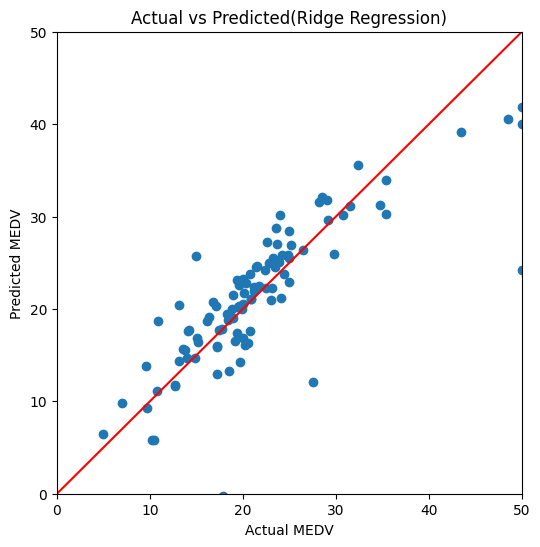

In [ ]:
import matplotlib.pyplot as plt
plt.figure(figsize=(6,6))
plt.scatter(y_test,y_pred)
max_val=max(y_test.max(),y_pred.max())
plt.plot([0,max_val],[0,max_val],color='red')
plt.xlim(0,max_val)
plt.ylim(0,max_val)
plt.xlabel("Actual MEDV")
plt.ylabel("Predicted MEDV")
plt.title("Actual vs Predicted(Ridge Regression)")
plt.show()

In [ ]:
from sklearn.linear_model import LinearRegression
lr=LinearRegression()
lr.fit(x_train,y_train)

LinearRegression()

In [ ]:
y_pred=lr.predict(x_test)

In [ ]:
print("Actual values:",y_test[:5])
print("Predicted values:",y_pred[:5])

Actual values: [[23.6]
 [32.4]
 [13.6]
 [22.8]
 [16.1]]
Predicted values: [[28.99672362]
 [36.02556534]
 [14.81694405]
 [25.03197915]
 [18.76987992]]


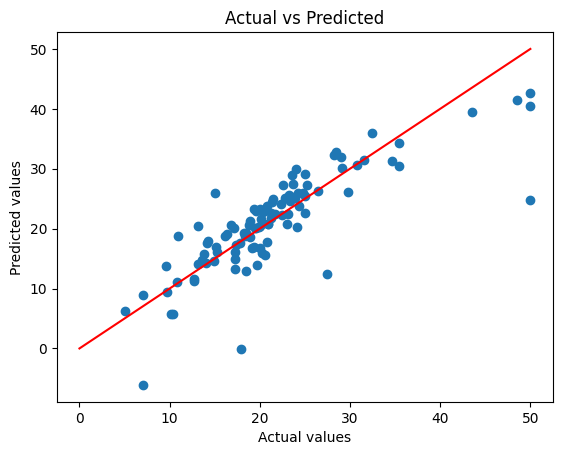

In [ ]:
plt.scatter(y_test,y_pred)
plt.plot([0,max_plot_val],[0,max_plot_val],color='red')
plt.xlabel("Actual values")
plt.ylabel("Predicted values")
plt.title("Actual vs Predicted")
plt.show()

In [ ]:
from sklearn.svm import SVR
svr=SVR(kernel="rbf",C=0.1,gamma=0.5)
svr.fit(x_train,y_train.ravel())

SVR(C=0.1, gamma=0.5)

In [ ]:
y_pred=svr.predict(x_test)

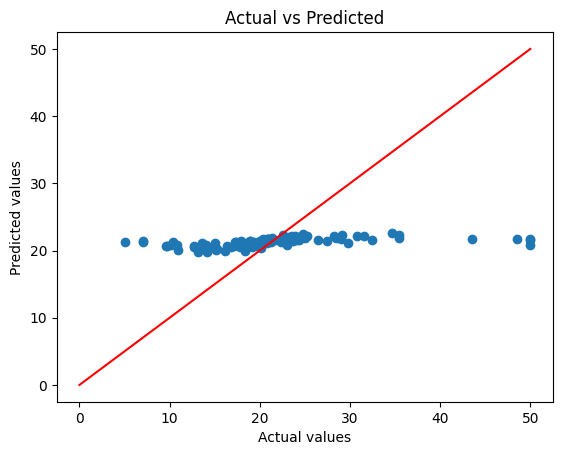

In [ ]:
plt.scatter(y_test,y_pred)
plt.plot([0,max_plot_val],[0,max_plot_val],color='red')
plt.xlabel("Actual values")
plt.ylabel("Predicted values")
plt.title("Actual vs Predicted")
plt.show()